# Clean Code

#### Daltonization, code taken partially from daltonize.org

In [11]:
import numpy as np
from PIL import Image
import sys

def daltonize(image_path, deficit='p'):
    im = Image.open(image_path).convert('RGB')
    rgb = np.asarray(im, dtype=float)
    
    # conversion from rgb to lms (in accordance to the cones in human eyes)
    rgb2lms = np.array([
        [17.8824, 43.5161, 4.11935],
        [3.45565, 27.1554, 3.86714],
        [0.0299566, 0.184309, 1.46709]
    ])

    lms2rgb = np.linalg.inv(rgb2lms)

    # simulation matrices (protanopia, deuteranopia, tritanopia)
    if deficit == 'p': 
        lms2lms_def = np.array([[0, 2.02344, -2.52581], [0, 1, 0], [0, 0, 1]])
        err2mod = np.array([[0, 0, 0], [0.7, 1, 0], [0.7, 0, 1]]) 
    elif deficit == 'd': 
        lms2lms_def = np.array([[1, 0, 0], [0.494207, 0, 1.24827], [0, 0, 1]])
        err2mod = np.array([[1, 0.7, 0], [0, 0, 0], [0, 0.7, 1]])
    elif deficit == 't': 
        lms2lms_def = np.array([[1, 0, 0], [0, 1, 0], [-0.395913, 0.801109, 0]])
        err2mod = np.array([[1, 0, 0.7], [0, 1, 0.7], [0, 0, 0]]) 

    # shifting the information to what the person can actually see
    lms = np.dot(rgb, rgb2lms.T)

    # simulation rgb
    lms_sim = np.dot(lms, lms2lms_def.T)
    rgb_sim = np.dot(lms_sim, lms2rgb.T)

    # error and modification
    error = rgb - rgb_sim
    err_mod = np.dot(error, err2mod.T)
    dtpn = err_mod + rgb

    result = np.clip(dtpn, 0, 255).astype('uint8')
    output_im = Image.fromarray(result)
    output_path = f"corrected_{deficit}_{image_path}"
    output_im.save(output_path)
    print(f"Success! Saved as {output_path}")

image_name = "red_green_text.png"
daltonize(image_name, 'p')

Success! Saved as corrected_p_red_green_text.png


#### Contrast enhancement

In [12]:
from skimage import color, filters

def apply_contrast_enforcement(original_rgb, corrected_rgb):
    # convert to lab colour space 
    orig_lab = color.rgb2lab(original_rgb)
    corr_lab = color.rgb2lab(corrected_rgb)
    
    # lighness
    L_orig = orig_lab[:,:,0]
    
    # detect edges 
    edge_mask = filters.sobel(color.rgb2gray(original_rgb))
    local_bg_L = filters.gaussian(L_orig, sigma=3)
    
    # increase contrast based on the average colour around a pixel
    enhanced_L = np.where(L_orig < local_bg_L, L_orig * 0.8, L_orig * 1.2) 
    
    # blend and change only where there's an edge
    final_L = (enhanced_L * edge_mask) + (L_orig * (1 - edge_mask))
    corr_lab[:,:,0] = np.clip(final_L, 0, 100)

    return color.lab2rgb(corr_lab)

#### Final image

In [13]:
original_image = Image.open(image_name).convert('RGB')
corrected_image = Image.open("corrected_p_red_green_text.png").convert('RGB')
contrast_rgb = apply_contrast_enforcement(original_image, corrected_image)

final_array = np.clip(contrast_rgb * 255, 0, 255).astype(np.uint8)
final_image = Image.fromarray(final_array)
output_path = "final_contrast_red_green_text.png"
final_image.save(output_path)

print(f"Successfully saved contrast-enhanced image to {output_path}")

Successfully saved contrast-enhanced image to final_contrast_red_green_text.png


#### To print the edges

In [ ]:
from skimage import color, filters

def print_edges(original_rgb):
    edge_mask = filters.sobel(color.rgb2gray(original_rgb))
    mask_to_print = np.clip(edge_mask * 255, 0, 255).astype(np.uint8)
    mask_image = Image.fromarray(mask_to_print)
    display(mask_image)

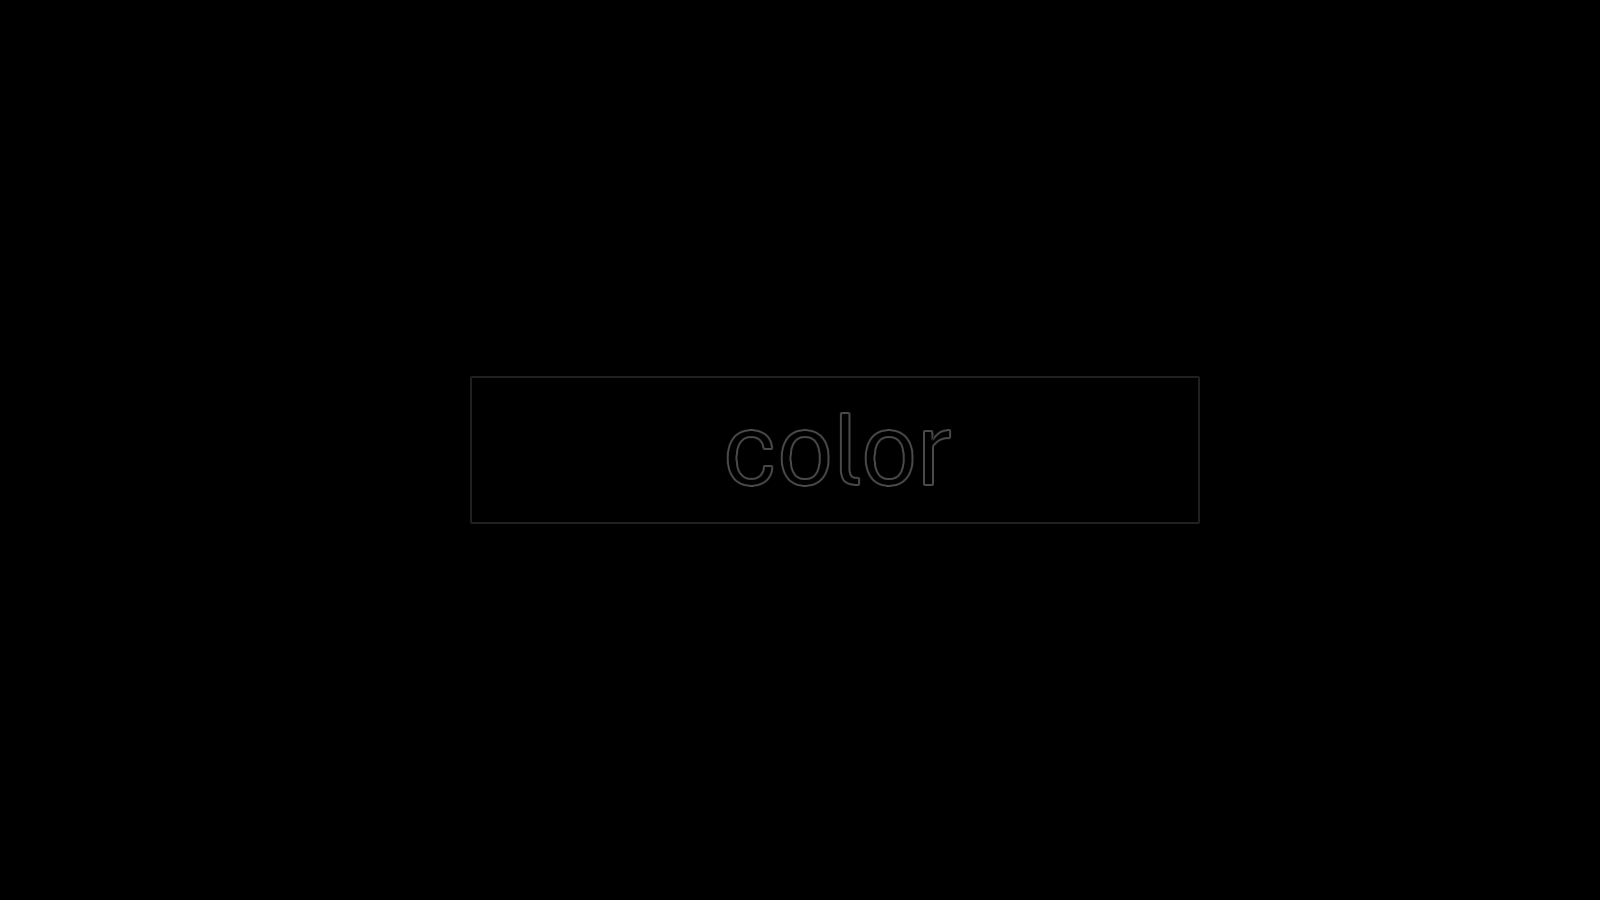

In [15]:
original_image = Image.open("red_green_text.png").convert('RGB')
print_edges(original_image)